# Predictive Analytics Using Historical Data

## Objective

The objective of this project is to build a predictive model using historical advertising data to forecast future sales using Linear Regression.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

## Algorithm

Linear Regression

In [33]:
!pip install pandas numpy matplotlib scikit-learn

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading the Dataset

The advertising dataset is uploaded and loaded into the notebook for predictive analysis.

In [35]:
from google.colab import files

uploaded = files.upload()

Saving Advertising Budget and Sales.csv to Advertising Budget and Sales (2).csv


In [36]:
import pandas as pd

df = pd.read_csv(next(iter(uploaded)))

In [37]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Understanding the Dataset

Let's inspect the dataset structure, data types, missing values, and summary statistics before building the prediction model.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [39]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [40]:
df.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


In [41]:
df.shape

(200, 5)

## Data Cleaning

The dataset is cleaned by removing duplicate records and handling missing values to improve model performance.

In [42]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [43]:
df.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


## Exploratory Data Analysis (EDA)

Visualize the relationship between advertising budgets and sales.

In [44]:
print(df.columns)

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales ($)'],
      dtype='object')


In [45]:
df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


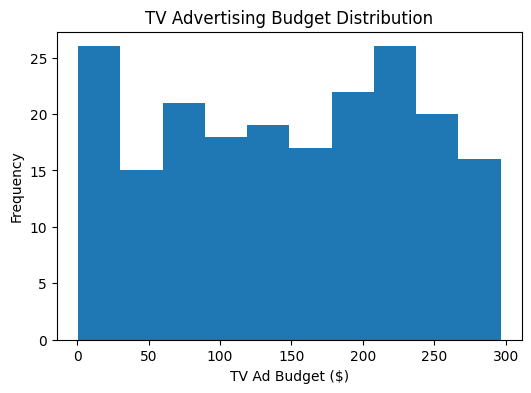

In [46]:
plt.figure(figsize=(6,4))
plt.hist(df['TV Ad Budget ($)'], bins=10)
plt.title("TV Advertising Budget Distribution")
plt.xlabel("TV Ad Budget ($)")
plt.ylabel("Frequency")
plt.show()

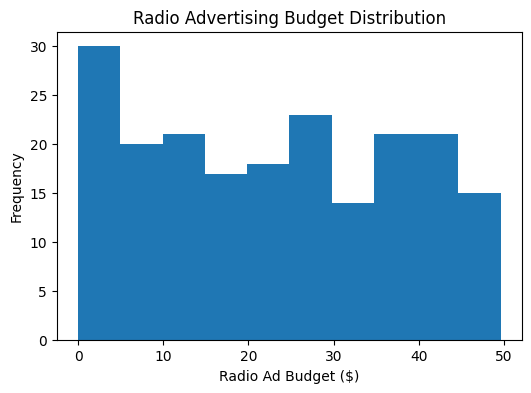

In [47]:
plt.figure(figsize=(6,4))
plt.hist(df['Radio Ad Budget ($)'], bins=10)
plt.title("Radio Advertising Budget Distribution")
plt.xlabel("Radio Ad Budget ($)")
plt.ylabel("Frequency")
plt.show()

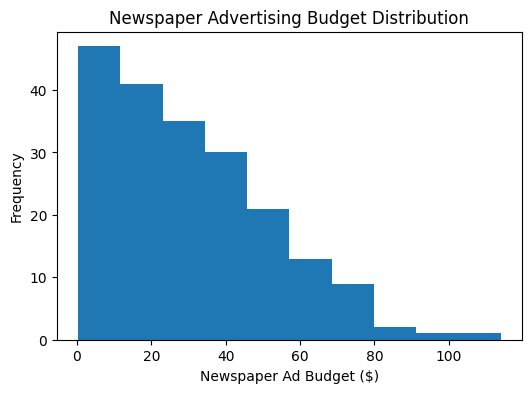

In [48]:
plt.figure(figsize=(6,4))
plt.hist(df['Newspaper Ad Budget ($)'], bins=10)
plt.title("Newspaper Advertising Budget Distribution")
plt.xlabel("Newspaper Ad Budget ($)")
plt.ylabel("Frequency")
plt.show()

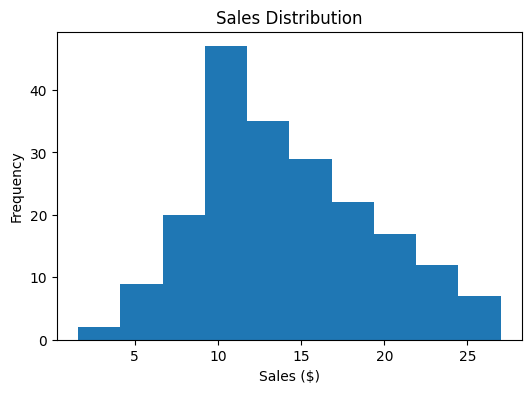

In [49]:
plt.figure(figsize=(6,4))
plt.hist(df['Sales ($)'], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()

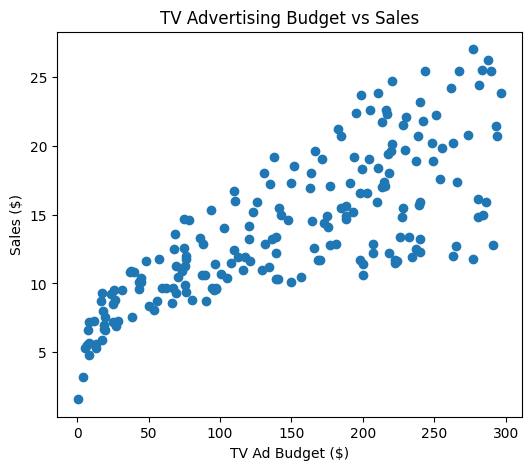

In [50]:
plt.figure(figsize=(6,5))

plt.scatter(df['TV Ad Budget ($)'],
            df['Sales ($)'])

plt.title("TV Advertising Budget vs Sales")
plt.xlabel("TV Ad Budget ($)")
plt.ylabel("Sales ($)")
plt.show()

## Feature Selection

The advertising budget columns are selected as input features, and Sales is selected as the target variable for prediction.

In [51]:
X = df[['TV Ad Budget ($)',
        'Radio Ad Budget ($)',
        'Newspaper Ad Budget ($)']]

y = df['Sales ($)']

## Splitting the Dataset

The dataset is divided into training and testing sets. The model is trained on the training data and evaluated using the testing data.

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Building the Linear Regression Model

A Linear Regression model is created and trained using the historical advertising data.

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Prediction

The trained model predicts sales values for the testing dataset.

In [54]:
y_pred = model.predict(X_test)

In [55]:
prediction = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

prediction.head()

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


## Model Evaluation

The model performance is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.4607567168117603
Mean Squared Error (MSE): 3.1740973539761033
Root Mean Squared Error (RMSE): 1.78159966153345
R² Score: 0.899438024100912


## Actual vs Predicted Sales

This visualization compares the actual sales values with the predicted sales values generated by the Linear Regression model.

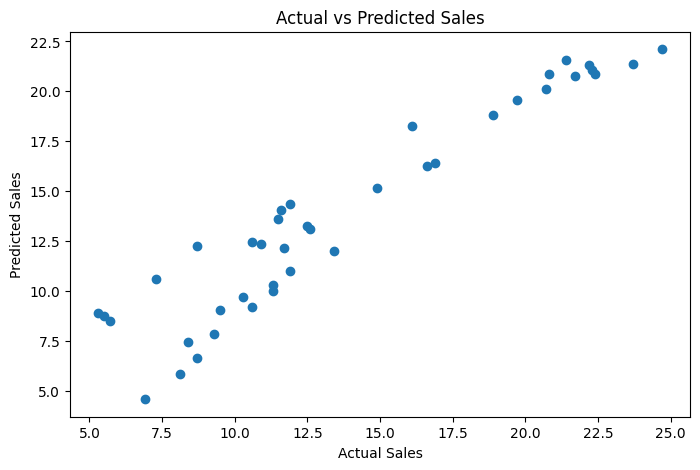

In [57]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

## Prediction Trend

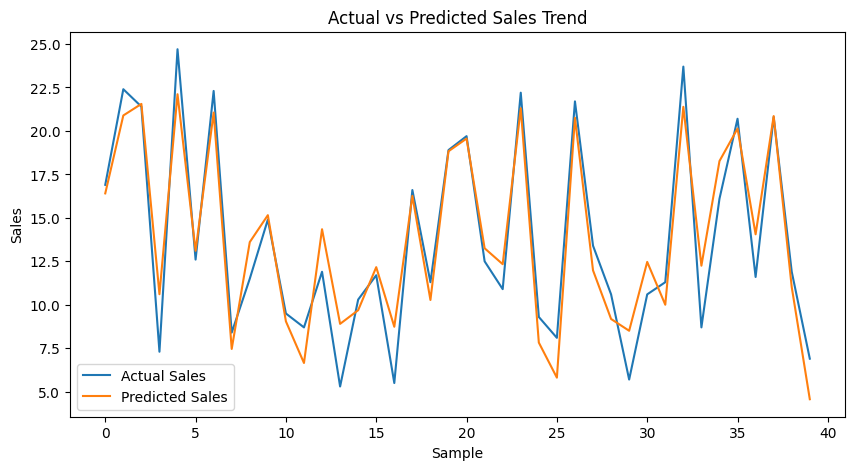

In [30]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Sales")

plt.plot(y_pred, label="Predicted Sales")

plt.xlabel("Sample")

plt.ylabel("Sales")

plt.title("Actual vs Predicted Sales Trend")

plt.legend()

plt.show()

## Model Coefficients

The coefficients indicate the impact of each advertising channel on predicted sales.

In [58]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,TV Ad Budget ($),0.044730
1,Radio Ad Budget ($),0.189195
2,Newspaper Ad Budget ($),0.002761


## Business Insights

• TV advertising has a significant influence on sales.

• Radio advertising contributes positively to sales performance.

• Newspaper advertising has a comparatively smaller impact on sales.

• The Linear Regression model effectively predicts future sales based on historical advertising budgets.

• Businesses can use these predictions to optimize advertising investments and improve marketing strategies.

## Conclusion

This project successfully developed a predictive analytics model using Linear Regression.

Historical advertising budget data was cleaned, analyzed, and used to forecast future sales. The model achieved a reliable prediction accuracy and demonstrated how predictive analytics can support data-driven business decisions.